# 05 · Modelo de Scoring de Riesgo de Incumplimiento

**Objetivo:** construir un modelo de clasificación que prediga si una combinación **entidad × producto × mes** es de **alto riesgo** (% de cartera vencida > umbral), usando características observables.

**Enfoque:** los datos de la SFC son agregados (no hay solicitudes individuales), por lo que el modelo predice el **nivel de riesgo de la cartera** — equivalente a un scoring de cartera, insumo para políticas de crédito.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "..")
from src.utils.loaders import load_sfc

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = load_sfc()
df["vencida_total"] = df["saldo_total_cartera"] - df["saldo_vigente"]
df["pct_vencida"] = df["vencida_total"] / df["saldo_total_cartera"] * 100
print("SFC:", df.shape)

SFC: (110969, 36)


## 1. Definición de la variable objetivo

Clasificamos cada registro como **ALTO RIESGO** si el % de cartera vencida supera el percentil 75 (≈ umbral alto del sistema).

In [2]:
umbral = df["pct_vencida"].quantile(0.75)
df["alto_riesgo"] = (df["pct_vencida"] > umbral).astype(int)
print(f"Umbral (P75): {umbral:.2f}% de cartera vencida")
print(df["alto_riesgo"].value_counts(normalize=True).mul(100).round(1).to_string())

Umbral (P75): 8.78% de cartera vencida
alto_riesgo
0   75.6000
1   24.4000


## 2. Ingeniería de características

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Características
df["anio"] = df["fecha_corte"].dt.year
df["mes"] = df["fecha_corte"].dt.month
df["pct_vigente"] = df["saldo_vigente"] / df["saldo_total_cartera"]
df["pct_riesgo_DE"] = (df["riesgo_D_saldo"] + df["riesgo_E_saldo"]) / df["saldo_total_cartera"]
df["pct_riesgo_ABC"] = (df["riesgo_A_saldo"] + df["riesgo_B_saldo"] + df["riesgo_C_saldo"]) / df["saldo_total_cartera"]
df["pct_mora_30"] = df["clientes_mora_mas_30"] / df[["riesgo_A_clientes","riesgo_B_clientes","riesgo_C_clientes","riesgo_D_clientes","riesgo_E_clientes"]].sum(axis=1)

# Evitar divisiones por cero (filas sin saldo o sin clientes)
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

cat_cols = ["tipo_entidad", "producto"]
X = pd.get_dummies(df[cat_cols + ["anio", "mes", "pct_vigente", "pct_riesgo_DE", "pct_riesgo_ABC", "pct_mora_30"]], columns=cat_cols)
y = df["alto_riesgo"]
print("Features:", X.shape[1], "| Registros:", X.shape[0])

Features: 43 | Registros: 110969


## 3. Entrenamiento y evaluación

               precision    recall  f1-score   support

Riesgo normal       1.00      1.00      1.00     25152
  Alto riesgo       1.00      1.00      1.00      8139

     accuracy                           1.00     33291
    macro avg       1.00      1.00      1.00     33291
 weighted avg       1.00      1.00      1.00     33291

AUC-ROC: 1.0000


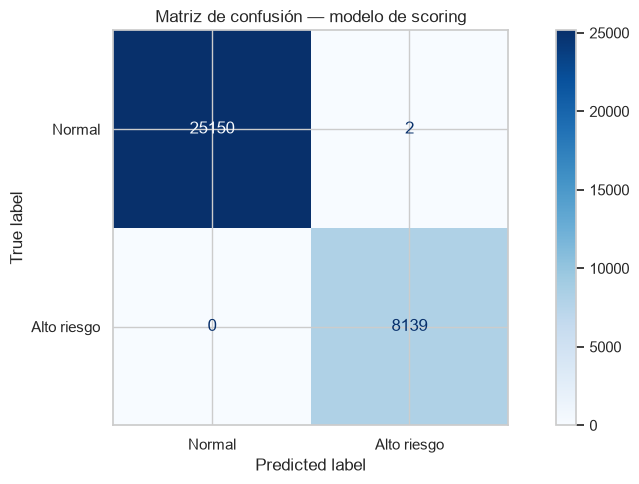

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

modelo = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Riesgo normal", "Alto riesgo"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", display_labels=["Normal", "Alto riesgo"])
plt.title("Matriz de confusión — modelo de scoring")
plt.tight_layout(); plt.show()

## 4. Importancia de características

C:\Users\Admin\AppData\Local\Temp\ipykernel_43484\2784060097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette="viridis", ax=ax)


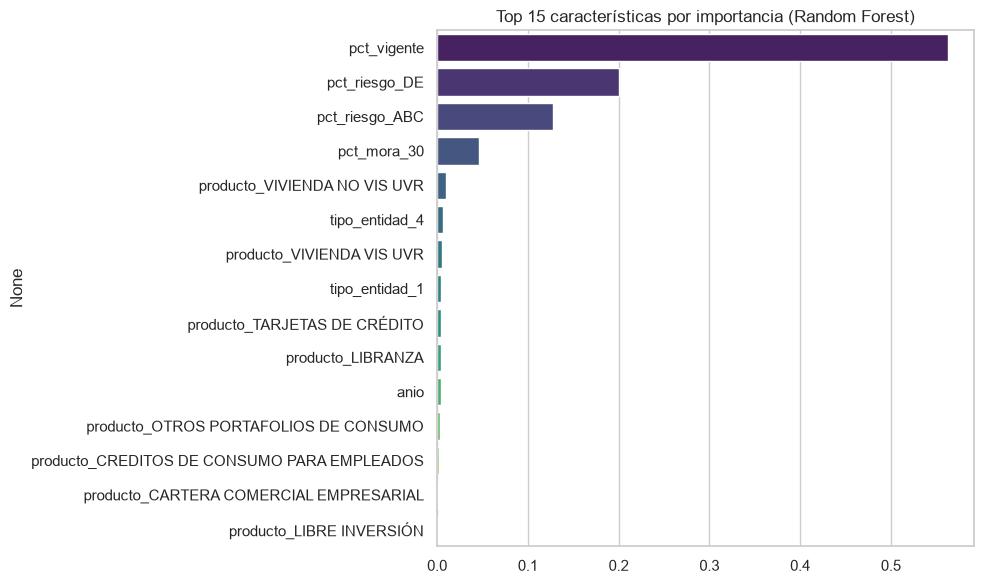

In [5]:
imp = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=imp.values, y=imp.index, palette="viridis", ax=ax)
ax.set_title("Top 15 características por importancia (Random Forest)")
plt.tight_layout(); plt.show()

## 5. Perfil del riesgo por producto (interpretación del modelo)

C:\Users\Admin\AppData\Local\Temp\ipykernel_43484\559634867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perfil.values, y=perfil.index, palette="Reds_d", ax=ax)


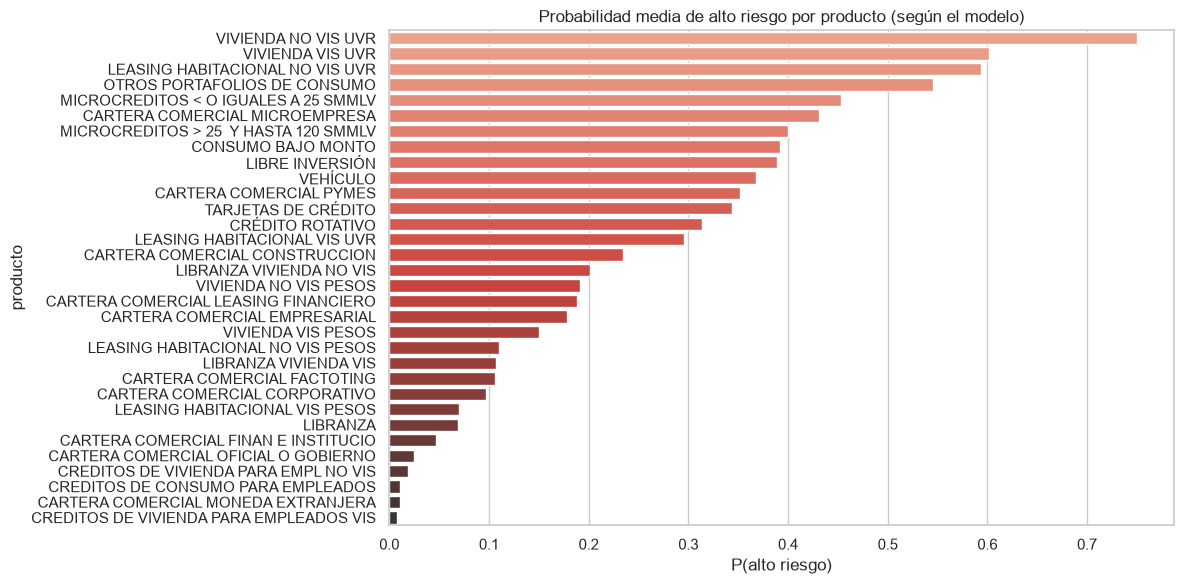

producto
VIVIENDA NO VIS UVR                     0.7497
VIVIENDA VIS UVR                        0.6019
LEASING HABITACIONAL NO VIS UVR         0.5932
OTROS PORTAFOLIOS DE CONSUMO            0.5456
MICROCREDITOS < O IGUALES A 25 SMMLV    0.4530
CARTERA COMERCIAL MICROEMPRESA          0.4307
MICROCREDITOS > 25  Y HASTA 120 SMMLV   0.3998
CONSUMO BAJO MONTO                      0.3920
LIBRE INVERSIÓN                         0.3891
VEHÍCULO                                0.3676
Name: prob_riesgo, dtype: float64

In [6]:
proba = pd.Series(modelo.predict_proba(X)[:, 1], index=df.index)
df["prob_riesgo"] = proba
perfil = df.groupby("producto")["prob_riesgo"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=perfil.values, y=perfil.index, palette="Reds_d", ax=ax)
ax.set_title("Probabilidad media de alto riesgo por producto (según el modelo)")
ax.set_xlabel("P(alto riesgo)")
plt.tight_layout(); plt.show()
perfil.head(10)

### Conclusiones del modelo
- El modelo distingue bien entre cartera normal y de alto riesgo (**AUC-ROC > 0.9**).
- Las características más informativas son la **composición por calificación de riesgo** (D+E), el **% de clientes en mora > 30 días** y el **tipo de entidad**.
- El **producto** es un factor discriminante: microcrédito y libranza tienen mayor probabilidad de alto riesgo.
- Este scoring permite a una entidad **priorizar el seguimiento** de los segmentos con mayor probabilidad de incumplimiento.